This notebook reproduces the full experiment and figures of the paper:

> *Comparison of methods for ARIMA model identification*

The actual logic lives in the modules under `src/`. Here we just orchestrate the run, normalize the results, and produce the figures and tables that appear in the paper.

#### 1. Imports and data collection


In [1]:
# --- imports ---
import gc
import os
from pathlib import Path

import numpy as np
import pandas as pd
from joblib import Parallel, delayed

from src.data_api import *
from src.data import *
from src.selection import *
from src.pipeline import *
from src.analysis import *
from src.plotting import *

# Output directories
DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
FIGURES_DIR = Path('figures')
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


In [2]:
# --- data collection ---
# Download the ONS daily streamflow dataset
# Truncated at 31 January 2026 for reproducibility
product = 'dados-hidrologicos-res'
df = collect_data('ons', product)
df['din_instante'] = pd.to_datetime(df['din_instante'])
df = df[df['din_instante'] <= '2026-01-31'].copy()
print(f'Rows after truncation: {len(df):,}')

Starting download of 27 files...
Rows after truncation: 1,555,961


#### 2. Filtering, characterization and pipeline execution

Pre-filters reservoirs with at least 25 years of complete daily data, then runs the four selection methods in parallel for each. Results are checkpointed to `results/selection_results.csv` so the run can be safely interrupted and resumed.


In [3]:
# --- filter and prepare daily series ---
all_reservoirs = df['nom_reservatorio'].unique()
print(f'Total reservoirs in the dataset: {len(all_reservoirs)}')

print('Pre-filtering reservoirs...\n')
valid_reservoirs = []
for name in all_reservoirs:
    series_tmp = prepare_daily_series(df, name)
    if series_tmp is not None and len(series_tmp) >= 365 * 25:
        valid_reservoirs.append(name)
    del series_tmp
gc.collect()

print('Preparing series...')
series_map = {}
for name in valid_reservoirs:
    series = prepare_daily_series(df, name)
    if series is not None:
        series_map[name] = series

n_total = len(series_map)
print(f'Valid reservoirs (no gaps and >= 365*25 obs): {n_total}')

range_p = range(0, 6)
range_d = range(0, 3)
range_q = range(0, 6)

Total reservoirs in the dataset: 184
Pre-filtering reservoirs...

Preparing series...
Valid reservoirs (no gaps and >= 365*25 obs): 147


In [4]:
# --- ADF + KPSS classification ---
df_est = classify_stationarity(series_map, alpha=0.05)
df_est.to_csv(RESULTS_DIR / 'stationarity.csv', index=False)

print(f'Stationarity classification (alpha = 0.05)\n')
counts = df_est['classificacao'].value_counts()
for cat, n in counts.items():
    print(f'  {cat}: {n} ({n / len(df_est) * 100:.1f}%)')
print(f'  Total: {len(df_est)}')

c:\Users\PersioPuertasGarciaL\Downloads\arima-selection-paper\src\data.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(series, regression="c", nlags="auto")
c:\Users\PersioPuertasGarciaL\Downloads\arima-selection-paper\src\data.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(series, regression="c", nlags="auto")
c:\Users\PersioPuertasGarciaL\Downloads\arima-selection-paper\src\data.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(series, regression="c", nlags="auto")
c:\Users\PersioPuertasGarciaL\Downloads\arima-selection-paper\src\data.py:43: InterpolationWarnin

Stationarity classification (alpha = 0.05)

  Nao estacionaria no kpss: 86 (58.5%)
  Estacionaria: 61 (41.5%)
  Total: 147


c:\Users\PersioPuertasGarciaL\Downloads\arima-selection-paper\src\data.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression="c", nlags="auto")


In [5]:
# --- parallel execution with resume support ---
checkpoint = RESULTS_DIR / 'selection_results.csv'
expected_columns = {'mae_val', 'rmse_val', 'pbias_val', 'ordem_val'}
already_done = set()

if checkpoint.exists():
    df_partial = pd.read_csv(checkpoint)
    if not expected_columns.issubset(df_partial.columns):
        print('Outdated checkpoint. Restarting from scratch.')
        checkpoint.unlink()
    else:
        already_done = set(df_partial['reservatorio'].unique())
        print(f'Resuming: {len(already_done)} reservoirs already processed.')

pending = {k: v for k, v in series_map.items() if k not in already_done}
print(f'Pending: {len(pending)} of {n_total}')

if len(pending) > 0:
    n_workers = max(1, (os.cpu_count() or 2) - 2)
    print(f'\nRunning pipeline in parallel with {n_workers} workers...\n')

    generator = Parallel(
        n_jobs=n_workers,
        verbose=10,
        backend='loky',
        return_as='generator_unordered',
    )(
        delayed(process_reservoir)(name, series, range_p, range_d, range_q, 10)
        for name, series in pending.items()
    )

    write_header = not checkpoint.exists()
    for result in generator:
        if result is not None:
            pd.DataFrame([result]).to_csv(
                checkpoint, mode='a', header=write_header, index=False
            )
            write_header = False

print(f'\nDone.')

Resuming: 147 reservoirs already processed.
Pending: 0 of 147

Done.


#### 3. Loading results

In [6]:
# --- load results and add normalized metrics ---
df_multi = pd.read_csv(checkpoint)
df_multi = normalize_metrics(df_multi, series_map)
df_multi_limpo, df_outliers = remove_outliers(df_multi)

print(f'Total reservoirs: {len(df_multi)}')
print(f'After outlier removal: {len(df_multi_limpo)}')
if len(df_outliers) > 0:
    print(f'Outliers (excluded from boxplots): {", ".join(df_outliers["reservatorio"].tolist())}')

Total reservoirs: 147
After outlier removal: 146
Outliers (excluded from boxplots): PEREIRA PASSOS


#### 4. Histograms of selected components

Saved histograms to figures/


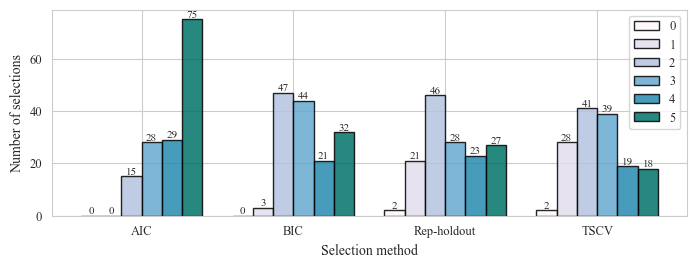

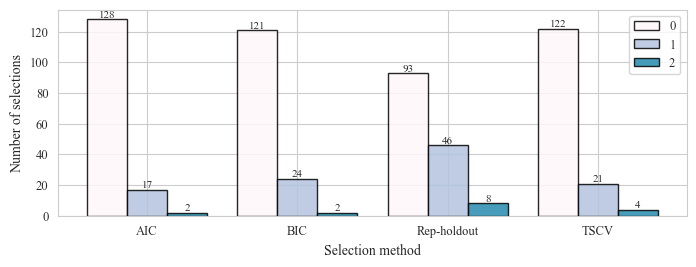

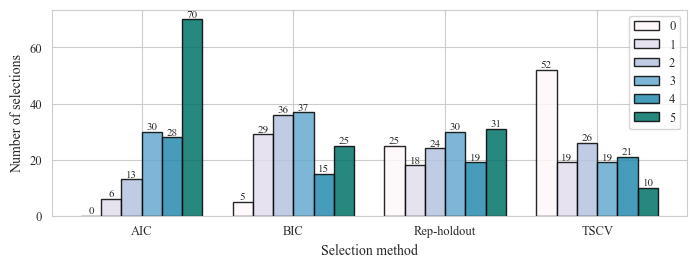

In [7]:
# --- Figs. 5, 6, 7: distribution of selected p, d, q across the four methods ---
plot_component_histogram(df_multi, 0, list(range(0, 6)),
                         FIGURES_DIR / 'histograms_p.png')
plot_component_histogram(df_multi, 1, list(range(0, 3)),
                         FIGURES_DIR / 'histograms_d.png')
plot_component_histogram(df_multi, 2, list(range(0, 6)),
                         FIGURES_DIR / 'histograms_q.png')
print(f'Saved histograms to {FIGURES_DIR}/')

#### 5. Agreement between methods

In [8]:
# --- Table 1: pairwise agreement on selected ARIMA orders ---
agreement = agreement_matrix(df_multi)
n_total = len(df_multi)

# Display lower triangle only as percentages
print(f'Agreement on selected (p, d, q) orders (N = {n_total})\n')
labels = METHOD_LABELS
for i in range(1, len(labels)):
    for j in range(i):
        n = agreement.iloc[i, j]
        pct = n / n_total * 100
        print(f'  {labels[i]:<12s} vs {labels[j]:<12s}: {n}/{n_total} ({pct:.0f}%)')

Agreement on selected (p, d, q) orders (N = 147)

  BIC          vs AIC         : 41/147 (28%)
  Rep-holdout  vs AIC         : 7/147 (5%)
  Rep-holdout  vs BIC         : 9/147 (6%)
  TSCV         vs AIC         : 10/147 (7%)
  TSCV         vs BIC         : 15/147 (10%)
  TSCV         vs Rep-holdout : 16/147 (11%)


#### 6. Boxplots of metrics

In [9]:
# --- Figs. 8, 9, 10: boxplots of NMAE, NRMSE, PBIAS ---
plot_boxplot(df_multi_limpo, 'nmae', 'NMAE',
             FIGURES_DIR / 'boxplot_nmae.png')
plot_boxplot(df_multi_limpo, 'nrmse', 'NRMSE',
             FIGURES_DIR / 'boxplot_nrmse.png')
plot_boxplot(df_multi_limpo, 'pbias', 'PBIAS (%)',
             FIGURES_DIR / 'boxplot_pbias.png', draw_zero_line=True)
print(f'Saved boxplots to {FIGURES_DIR}/')

Saved boxplots to figures/


#### 7. Wins per method and Friedman / Nemenyi

In [10]:
# --- Fig. 11: heatmap of wins per metric (all series) ---
plot_wins_heatmap(df_multi, FIGURES_DIR / 'heatmap_wins_all.png')
print(f'Saved: {FIGURES_DIR / "heatmap_wins_all.png"}')

Saved: figures\heatmap_wins_all.png


In [11]:
# --- Mean ranks for all metrics (clean dataset) ---
for metric_name, code in [('NMAE', 'nmae'), ('NRMSE', 'nrmse'), ('|PBIAS|', 'pbias')]:
    data = metric_frame(df_multi_limpo, code)
    ranks = mean_ranks(data).sort_values()
    print(f'\n{metric_name} mean ranks (N = {len(df_multi_limpo)}):')
    for method, r in ranks.items():
        print(f'  {method:<12s} {r:.2f}')


NMAE mean ranks (N = 146):
  Rep-holdout  2.14
  BIC          2.50
  AIC          2.60
  TSCV         2.76

NRMSE mean ranks (N = 146):
  BIC          2.30
  AIC          2.41
  Rep-holdout  2.45
  TSCV         2.83

|PBIAS| mean ranks (N = 146):
  Rep-holdout  2.26
  AIC          2.35
  BIC          2.57
  TSCV         2.83


In [12]:
# --- Friedman + Nemenyi for all series ---
n_all = len(df_multi_limpo)
print(f'Friedman test - all series (N = {n_all})')
print('=' * 70)
df_friedman_all, df_nemenyi_all = friedman_nemenyi_tables(df_multi_limpo)
print(df_friedman_all.to_string(index=False))

print(f'\nNemenyi post-hoc - all series (N = {n_all})')
print('-' * 70)
print(df_nemenyi_all.to_string(index=False))

Friedman test - all series (N = 146)
 Metric  chi2    p-value
   NMAE 19.93 1.7527e-04
  NRMSE 15.05 1.7755e-03
|PBIAS| 18.10 4.1952e-04

Nemenyi post-hoc - all series (N = 146)
----------------------------------------------------------------------
 Metric                Pair p-value Sig.
   NMAE          AIC vs BIC  0.9130   ns
   NMAE  AIC vs Rep-holdout  0.0119    *
   NMAE         AIC vs TSCV  0.6969   ns
   NMAE  BIC vs Rep-holdout  0.0766   ns
   NMAE         BIC vs TSCV  0.3003   ns
   NMAE Rep-holdout vs TSCV  0.0002  ***
  NRMSE          AIC vs BIC  0.8776   ns
  NRMSE  AIC vs Rep-holdout  0.9946   ns
  NRMSE         AIC vs TSCV  0.0291    *
  NRMSE  BIC vs Rep-holdout  0.7510   ns
  NRMSE         BIC vs TSCV  0.0025   **
  NRMSE Rep-holdout vs TSCV  0.0575   ns
|PBIAS|          AIC vs BIC  0.4538   ns
|PBIAS|  AIC vs Rep-holdout  0.9420   ns
|PBIAS|         AIC vs TSCV  0.0082   **
|PBIAS|  BIC vs Rep-holdout  0.1734   ns
|PBIAS|         BIC vs TSCV  0.3237   ns
|PBIAS| Rep-h

#### 8. Non-stationary subset (Fig. 12, Table 3)

In [13]:
# --- Subset: non-stationary series only ---
df_merged = df_multi.merge(
    df_est[['reservatorio', 'classificacao']],
    on='reservatorio',
    how='inner',
)
df_merged_limpo, _ = remove_outliers(df_merged)

df_ns = df_merged[df_merged['classificacao'] != 'Estacionaria']
df_ns_limpo = df_merged_limpo[df_merged_limpo['classificacao'] != 'Estacionaria']
print(f'Non-stationary series: {len(df_ns)} (clean: {len(df_ns_limpo)})')

Non-stationary series: 86 (clean: 86)


In [14]:
# --- Fig. 12: heatmap of wins on the non-stationary subset ---
plot_wins_heatmap(df_ns, FIGURES_DIR / 'heatmap_wins_nonstat.png')
print(f'Saved: {FIGURES_DIR / "heatmap_wins_nonstat.png"}')

Saved: figures\heatmap_wins_nonstat.png


In [15]:
# --- Mean ranks for all metrics (clean dataset) ---
for metric_name, code in [('NMAE', 'nmae'), ('NRMSE', 'nrmse'), ('|PBIAS|', 'pbias')]:
    data = metric_frame(df_ns_limpo, code)
    ranks = mean_ranks(data).sort_values()
    print(f'\n{metric_name} mean ranks (N = {len(df_ns_limpo)}):')
    for method, r in ranks.items():
        print(f'  {method:<12s} {r:.2f}')


NMAE mean ranks (N = 86):
  Rep-holdout  2.06
  AIC          2.55
  BIC          2.58
  TSCV         2.80

NRMSE mean ranks (N = 86):
  Rep-holdout  2.27
  BIC          2.40
  AIC          2.56
  TSCV         2.77

|PBIAS| mean ranks (N = 86):
  Rep-holdout  2.16
  AIC          2.42
  BIC          2.66
  TSCV         2.76


In [16]:
# --- Table 3: Friedman + Nemenyi for the non-stationary subset ---
n_ns = len(df_ns_limpo)
print(f'Friedman test - non-stationary series (N = {n_ns})')
print('=' * 70)
df_friedman_ns, df_nemenyi_ns = friedman_nemenyi_tables(df_ns_limpo)
print(df_friedman_ns.to_string(index=False))

print(f'\nNemenyi post-hoc - non-stationary series (N = {n_ns})')
print('-' * 70)
print(df_nemenyi_ns.to_string(index=False))

Friedman test - non-stationary series (N = 86)
 Metric  chi2    p-value
   NMAE 16.32 9.7499e-04
  NRMSE  7.74 5.1683e-02
|PBIAS| 12.08 7.1152e-03

Nemenyi post-hoc - non-stationary series (N = 86)
----------------------------------------------------------------------
 Metric                Pair p-value Sig.
   NMAE          AIC vs BIC  0.9989   ns
   NMAE  AIC vs Rep-holdout  0.0629   ns
   NMAE         AIC vs TSCV  0.5822   ns
   NMAE  BIC vs Rep-holdout  0.0426    *
   NMAE         BIC vs TSCV  0.6758   ns
   NMAE Rep-holdout vs TSCV  0.0010   **
  NRMSE          AIC vs BIC  0.8272   ns
  NRMSE  AIC vs Rep-holdout  0.4517   ns
  NRMSE         AIC vs TSCV  0.7297   ns
  NRMSE  BIC vs Rep-holdout  0.9257   ns
  NRMSE         BIC vs TSCV  0.2323   ns
  NRMSE Rep-holdout vs TSCV  0.0583   ns
|PBIAS|          AIC vs BIC  0.6200   ns
|PBIAS|  AIC vs Rep-holdout  0.5256   ns
|PBIAS|         AIC vs TSCV  0.3325   ns
|PBIAS|  BIC vs Rep-holdout  0.0500    *
|PBIAS|         BIC vs TSCV  0.965

#### 9. Capivara reservoir example

Illustrates the results with a single reservoir, including the traditional Box-Jenkins identification using ACF and PACF.

In [17]:
# --- Fig. 13: full Capivara series ---
import ast
from statsmodels.tsa.arima.model import ARIMA

example_name = 'CAPIVARA'
example_series = prepare_daily_series(df, example_name)

n_ex = len(example_series)
n_test_ex = round(n_ex * 0.15)
train_ex = example_series.iloc[:-n_test_ex]
test_ex = example_series.iloc[-n_test_ex:]

plot_capivara_series(example_series, FIGURES_DIR / 'capivara_series.png')
print(f'Saved: {FIGURES_DIR / "capivara_series.png"}')

Saved: figures\capivara_series.png


In [18]:
# --- Figs. 14, 15: ACF and PACF for the original and differenced series ---
plot_acf_pacf(example_series, FIGURES_DIR / 'capivara_acf_pacf_original.png')
plot_acf_pacf(example_series.diff().dropna(),
              FIGURES_DIR / 'capivara_acf_pacf_differenced.png')
print(f'Saved ACF/PACF plots to {FIGURES_DIR}/')

Saved ACF/PACF plots to figures/


In [ ]:
# --- Get orders selected by each method for Capivara, plus traditional (2,1,1) ---
row_ex = df_multi[df_multi['reservatorio'] == example_name].iloc[0]
orders = {
    'AIC':         ast.literal_eval(row_ex['ordem_aic']),
    'BIC':         ast.literal_eval(row_ex['ordem_bic']),
    'Rep-holdout': ast.literal_eval(row_ex['ordem_val']),
    'TSCV':        ast.literal_eval(row_ex['ordem_cv']),
    'Traditional': (2, 1, 1),
}

# Fit each model and generate test-set forecasts
forecasts = {}
for label, order in orders.items():
    model = ARIMA(train_ex, order=order).fit(low_memory=True)
    ext = model.append(test_ex, refit=False)
    forecasts[label] = np.array(ext.fittedvalues[-len(test_ex):])
    del model, ext

# Compute metrics on the test set (without normalization, since all
# models refer to the same series)
print(f'Capivara test-set metrics (n = {len(test_ex)} days)\n')
print(f'{"Approach":<14} {"Order":<10} {"MAE":>8} {"RMSE":>8} {"PBIAS (%)":>10}')
print('-' * 55)
for label, order in orders.items():
    m = compute_metrics(test_ex.values, forecasts[label])
    print(f'{label:<14} {str(order):<10} {m["MAE"]:>8.2f} {m["RMSE"]:>8.2f} {m["PBIAS"]:>10.2f}')

c:\Users\PersioPuertasGarciaL\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\PersioPuertasGarciaL\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\PersioPuertasGarciaL\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Capivara test-set metrics (n = 1429 days)

Approach       Order           MAE     RMSE  PBIAS (%)
-------------------------------------------------------
AIC            (2, 0, 5)     65.75   137.08       0.68
BIC            (1, 1, 4)     62.87   137.28      -0.06
Rep-holdout    (2, 1, 2)     62.74   136.73      -0.05
TSCV           (1, 1, 3)     63.10   137.37      -0.07
Traditional    (2, 1, 1)     61.87   139.92      -0.01


In [ ]:
# --- Fig. 16: first 180 days of test set forecasts ---
plot_capivara_forecasts(
    test_ex,
    forecasts,
    orders,
    FIGURES_DIR / 'capivara_forecasts.png',
    n_zoom=180,
)
print(f'Saved: {FIGURES_DIR / "capivara_forecasts.png"}')

Saved: figures\capivara_forecasts.png
